In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("car_prices.csv")
df.head()

,car_id,mileage,selling_price
0,A001,126958,9734
1,A002,151867,8775
2,A003,136932,3928
3,A004,108694,12454
4,A005,124879,6634


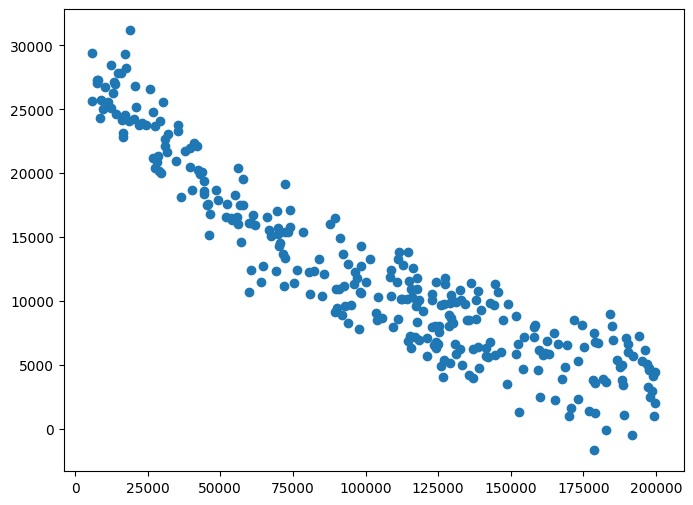

In [6]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(df.mileage,df.selling_price)
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

In [24]:
X=df[["mileage"]]
y=df["selling_price"]

X_train, X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=5)

In [25]:
X.shape

(300, 1)

In [26]:
X_test.shape

(60, 1)

In [27]:
# for my understanding
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
poly.fit_transform(np.array([[1],[2],[3]]))

array([[1., 1., 1.],
       [1., 2., 4.],
       [1., 3., 9.]])

In [28]:
poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.fit_transform(X_test)

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred=model.predict(X_test_poly)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [31]:
mse , r2

(3942449.0425903364, 0.9161450769964844)

In [36]:
x_range = np.linspace(X['mileage'].min(), X['mileage'].max(), 300).reshape(-1, 1)
x_range_poly = poly.transform(x_range)
y_range_pred = model.predict(x_range_poly)
x_range_poly

C:\Users\rushi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


array([[1.00000000e+00, 5.76900000e+03, 3.32813610e+07],
       [1.00000000e+00, 6.41795318e+03, 4.11901230e+07],
       [1.00000000e+00, 7.06690635e+03, 4.99411654e+07],
       [1.00000000e+00, 7.71585953e+03, 5.95344883e+07],
       [1.00000000e+00, 8.36481271e+03, 6.99700917e+07],
       [1.00000000e+00, 9.01376589e+03, 8.12479755e+07],
       [1.00000000e+00, 9.66271906e+03, 9.33681397e+07],
       [1.00000000e+00, 1.03116722e+04, 1.06330584e+08],
       [1.00000000e+00, 1.09606254e+04, 1.20135310e+08],
       [1.00000000e+00, 1.16095786e+04, 1.34782315e+08],
       [1.00000000e+00, 1.22585318e+04, 1.50271601e+08],
       [1.00000000e+00, 1.29074849e+04, 1.66603168e+08],
       [1.00000000e+00, 1.35564381e+04, 1.83777015e+08],
       [1.00000000e+00, 1.42053913e+04, 2.01793142e+08],
       [1.00000000e+00, 1.48543445e+04, 2.20651550e+08],
       [1.00000000e+00, 1.55032977e+04, 2.40352238e+08],
       [1.00000000e+00, 1.61522508e+04, 2.60895207e+08],
       [1.00000000e+00, 1.68012

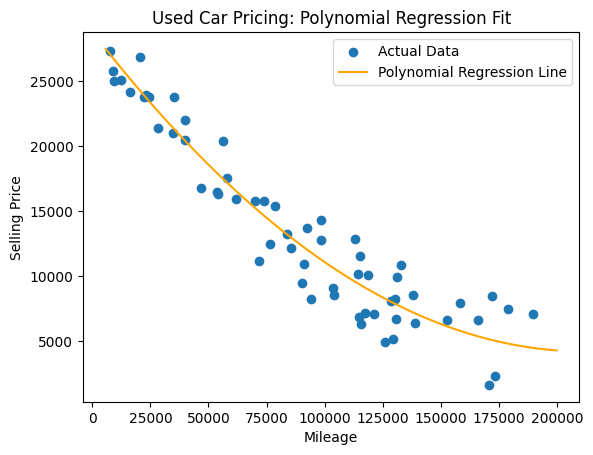

In [33]:
plt.scatter(X_test['mileage'], y_test, label='Actual Data')
plt.plot(x_range, y_range_pred, color='orange', label='Polynomial Regression Line')
plt.title('Used Car Pricing: Polynomial Regression Fit')
plt.xlabel('Mileage')
plt.ylabel('Selling Price')
plt.legend()
plt.show()